## Part A — Business Understanding & EDA

Load the dataset and investigate:

* shape and data types;
* missing values;
* descriptive statistics;
* churn distribution;
* numerical distributions;
* churn patterns by contract type and AutoPay.

Answer:

1. Which column must be excluded because it is an identifier?
2. Why should `Future12MRevenueEGP` not be used to predict current churn?
3. Is accuracy sufficient for churn prediction?
4. Which algorithms are sensitive to feature scaling?

=== Shape and Data Types ===
Shape: (3000, 16)

Data Types:
CustomerID              object
Age                      int64
Region                  object
TenureMonths             int64
ContractType            object
InternetType            object
MonthlyUsageGB         float64
MonthlyChargeEGP       float64
NumServices              int64
SupportCalls6M           int64
LatePayments12M          int64
PaperlessBilling        object
AutoPay                 object
SatisfactionScore      float64
Future12MRevenueEGP    float64
Churn                   object
dtype: object
----------------------------------------

=== Missing Values ===
CustomerID              0
Age                     0
Region                  0
TenureMonths            0
ContractType            0
InternetType           45
MonthlyUsageGB         75
MonthlyChargeEGP        0
NumServices             0
SupportCalls6M          0
LatePayments12M         0
PaperlessBilling        0
AutoPay                 0
SatisfactionScore      60
F

,Age,TenureMonths,MonthlyUsageGB,MonthlyChargeEGP,NumServices,SupportCalls6M,LatePayments12M,SatisfactionScore,Future12MRevenueEGP
count,3000.000000,3000.000000,2925.000000,3000.000000,3000.000000,3000.000000,3000.000000,2940.000000,3000.000000
mean,44.057667,25.540667,230.132855,487.345707,3.515000,2.206333,1.111000,3.486054,5361.156050
std,15.346319,16.525739,89.357331,118.451753,1.714085,1.503722,1.066016,1.013758,1479.868751
min,18.000000,1.000000,10.000000,142.400000,1.000000,0.000000,0.000000,1.000000,1529.370000
25%,31.000000,13.000000,169.500000,398.992500,2.000000,1.000000,0.000000,3.000000,4330.792500
50%,44.000000,22.000000,228.700000,484.995000,4.000000,2.000000,1.000000,4.000000,5274.620000
75%,57.000000,35.000000,290.400000,574.572500,5.000000,3.000000,2.000000,4.000000,6314.497500
max,70.000000,72.000000,597.900000,866.990000,6.000000,9.000000,6.000000,5.000000,11095.190000


/tmp/ipykernel_2476/2556162246.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', ax=axes[0, 0], palette='Set2')


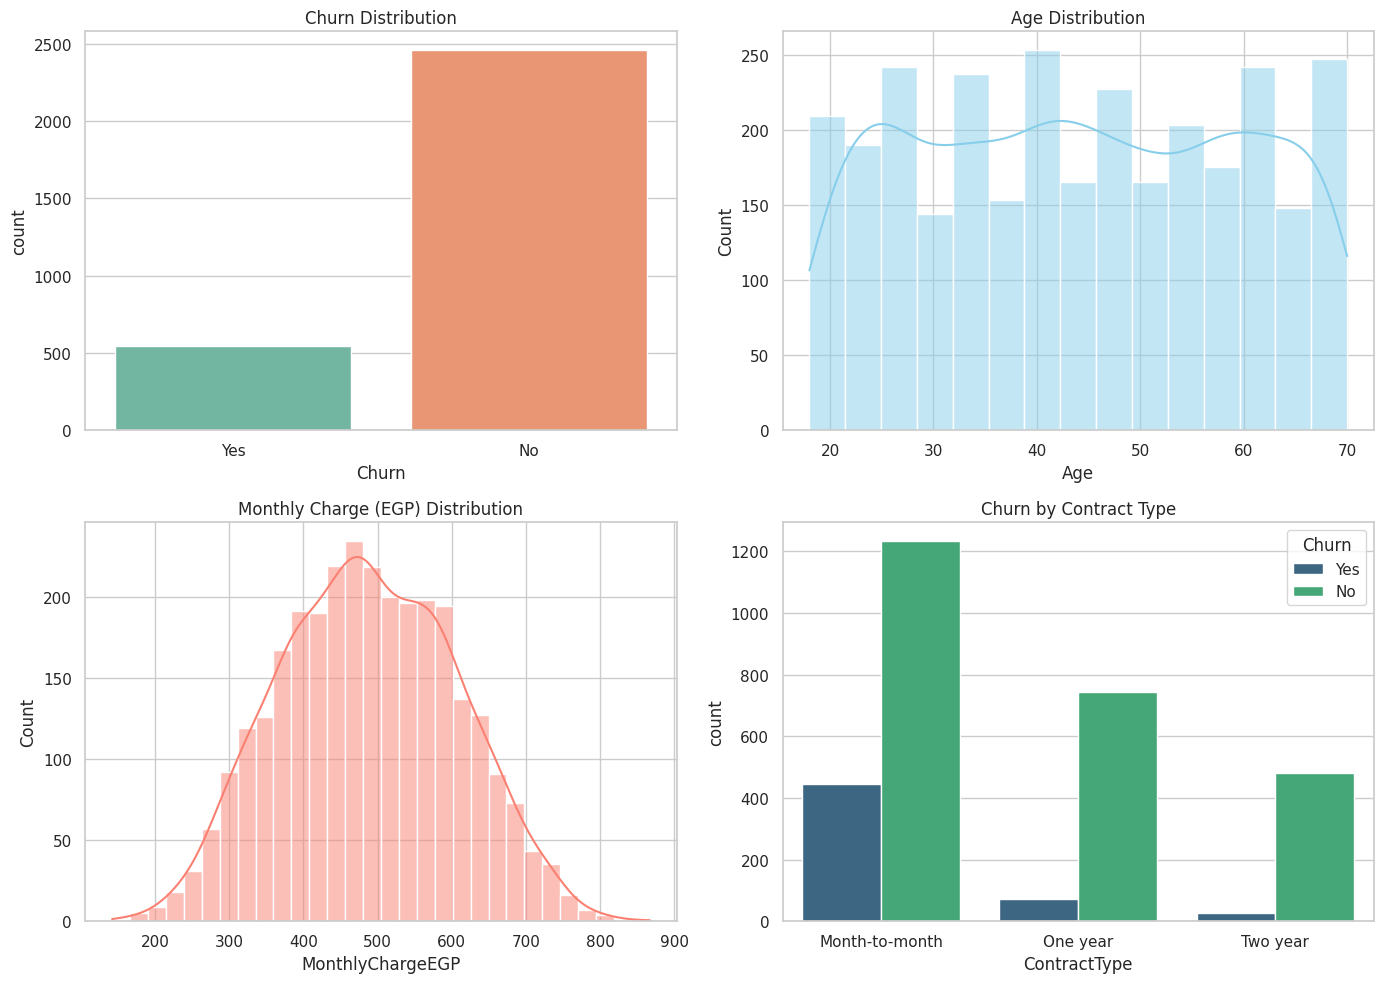

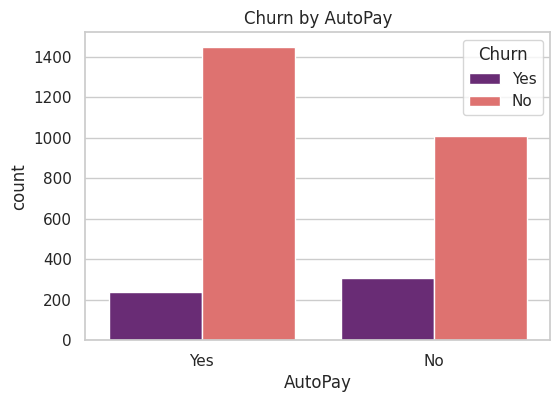

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('customer_360_ml_workshop.csv')

print("=== Shape and Data Types ===")
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("-" * 40)

print("\n=== Missing Values ===")
print(df.isnull().sum())
print("-" * 40)

print("\n=== Descriptive Statistics ===")
display(df.describe())

# Set up the visualization style
sns.set_theme(style="whitegrid")

# Create a figure for distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Churn distribution
sns.countplot(data=df, x='Churn', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Churn Distribution')

# 2. Numerical distributions (Examples: Age & MonthlyChargeEGP)
sns.histplot(data=df, x='Age', kde=True, ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Age Distribution')

sns.histplot(data=df, x='MonthlyChargeEGP', kde=True, ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Monthly Charge (EGP) Distribution')

# 3. Churn patterns by Contract Type
sns.countplot(data=df, x='ContractType', hue='Churn', ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Churn by Contract Type')

plt.tight_layout()
plt.show()

# 4. Churn patterns by AutoPay (Extra plot for clarity)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='AutoPay', hue='Churn', palette='magma')
plt.title('Churn by AutoPay')
plt.show()

## Part B — Data Preprocessing

Create a reusable preprocessing pipeline.
Requirements:
* median imputation for numerical variables;
* most-frequent imputation for categorical variables;
* standardization for numerical variables;
* one-hot encoding for categorical variables;
* `handle_unknown="ignore"`.

*Note: Do not fit preprocessing separately to the complete dataset before train/test splitting.*

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Define features (X) and target (y) for classification
# Exclude CustomerID (identifier) and Future12MRevenueEGP (target leakage)
X = df.drop(columns=['CustomerID', 'Future12MRevenueEGP', 'Churn'])
y_churn = df['Churn'].map({'Yes': 1, 'No': 0})

# 2. Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_churn, test_size=0.2, random_state=42, stratify=y_churn
)

# 3. Separate numerical and categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# 4. Create numerical pipeline
num_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
])

# 5. Create categorical pipeline (Updated for newer scikit-learn versions)
cat_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 6. Combine using ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols)
])

# 7. Apply preprocessing (fit on train, transform on train and test)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Data Preprocessing Completed Successfully!")
print(f"Original X_train shape: {X_train.shape}")
print(f"Processed X_train shape: {X_train_processed.shape}")

Data Preprocessing Completed Successfully!
Original X_train shape: (2400, 13)
Processed X_train shape: (2400, 23)


## Part C — Churn Classification

Target: `Churn`

Compare at least:
* Logistic Regression
* K-Nearest Neighbors
* Decision Tree
* Random Forest
* Support Vector Machine
* Naive Bayes
* Gradient Boosting

Report: Accuracy, Precision, Recall, F1, ROC-AUC.
Then:
* plot a confusion matrix;
* plot the ROC curve;
* tune Random Forest using GridSearchCV;
* identify important churn predictors.

In [5]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1. Define models dictionary
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(random_state=42, probability=True),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# 2. Train and evaluate each model
results = []

for name, model in models.items():
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

# 3. Display results sorted by ROC-AUC
results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)
display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.813333,0.459459,0.155963,0.232877,0.763897
1,Naive Bayes,0.750000,0.374233,0.559633,0.448529,0.760720
2,Gradient Boosting,0.808333,0.411765,0.128440,0.195804,0.732357
3,Random Forest,0.821667,0.541667,0.119266,0.195489,0.717857
4,Support Vector Machine,0.825000,0.700000,0.064220,0.117647,0.707870
5,K-Nearest Neighbors,0.791667,0.340000,0.155963,0.213836,0.597349
6,Decision Tree,0.710000,0.259259,0.321101,0.286885,0.558717


Tuning Random Forest. This might take a minute...
Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


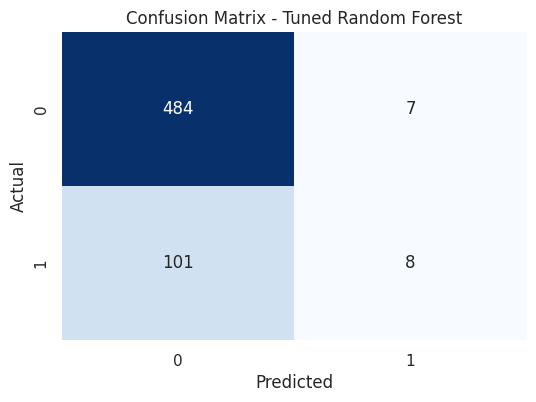

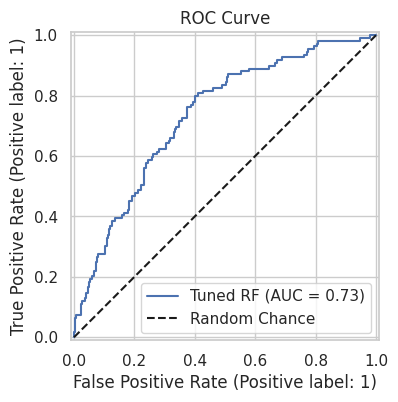

/tmp/ipykernel_2476/3057694452.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')


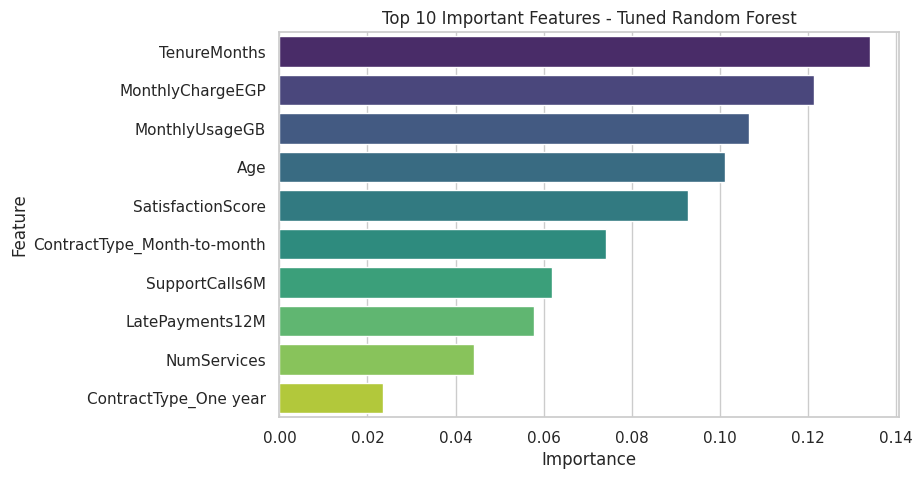

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, RocCurveDisplay
from sklearn.model_selection import GridSearchCV

# 1. Tune Random Forest using GridSearchCV
print("Tuning Random Forest. This might take a minute...")
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, rf_params, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train_processed, y_train)

best_rf = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

y_pred_best = best_rf.predict(X_test_processed)

# 2. Plot Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Tuned Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 3. Plot ROC Curve
fig, ax = plt.subplots(figsize=(6, 4))
RocCurveDisplay.from_estimator(best_rf, X_test_processed, y_test, ax=ax, name='Tuned RF')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.title('ROC Curve')
plt.legend()
plt.show()

# 4. Identify Important Churn Predictors
encoder = preprocessor.named_transformers_['cat'].named_steps['encoder']
cat_features = encoder.get_feature_names_out(cat_cols).tolist()
all_features = num_cols + cat_features

importances = best_rf.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Important Features - Tuned Random Forest')
plt.show()

## Part D — Revenue Regression

Target: `Future12MRevenueEGP`

Compare at least:
* Linear Regression
* Ridge
* Lasso
* KNN Regressor
* Decision Tree Regressor
* Random Forest Regressor
* Gradient Boosting Regressor

Report: MAE, RMSE, R².
Plot Actual Revenue vs Predicted Revenue.

,Model,MAE,RMSE,R2 Score
0,Gradient Boosting,368.560228,464.972316,0.896807
1,Ridge,378.416604,474.914752,0.892347
2,Linear Regression,378.426990,474.928058,0.892341
3,Lasso,378.672466,475.086263,0.892269
4,Random Forest,393.554831,496.139312,0.882510
5,Decision Tree,537.060217,683.953597,0.776721
6,KNN Regressor,619.291123,783.499159,0.706998


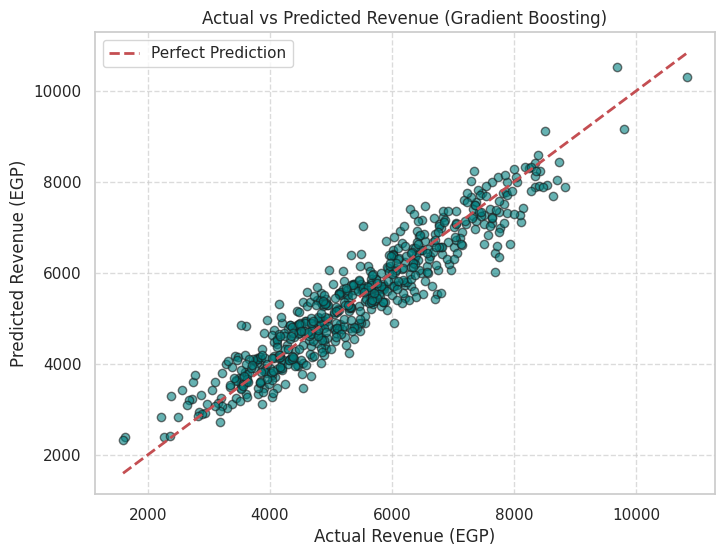

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

X_reg = df.drop(columns=['CustomerID', 'Future12MRevenueEGP', 'Churn'])
y_reg = df['Future12MRevenueEGP']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

X_train_reg_processed = preprocessor.fit_transform(X_train_reg)
X_test_reg_processed = preprocessor.transform(X_test_reg)

reg_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(random_state=42),
    "Lasso": Lasso(random_state=42),
    "KNN Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

reg_results = []
for name, model in reg_models.items():
    model.fit(X_train_reg_processed, y_train_reg)
    y_pred_reg = model.predict(X_test_reg_processed)

    reg_results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test_reg, y_pred_reg),
        "RMSE": np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)),
        "R2 Score": r2_score(y_test_reg, y_pred_reg)
    })

reg_results_df = pd.DataFrame(reg_results).sort_values(by="R2 Score", ascending=False).reset_index(drop=True)
display(reg_results_df)

best_model_name = reg_results_df.iloc[0]['Model']
best_model = reg_models[best_model_name]
y_pred_best = best_model.predict(X_test_reg_processed)

plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_best, alpha=0.6, color='teal', edgecolor='k')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Actual vs Predicted Revenue ({best_model_name})')
plt.xlabel('Actual Revenue (EGP)')
plt.ylabel('Predicted Revenue (EGP)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Part E — Customer Segmentation

Use behavioral/value variables: `TenureMonths`, `MonthlyUsageGB`, `MonthlyChargeEGP`, `NumServices`, `SupportCalls6M`, `LatePayments12M`, `SatisfactionScore`.

Apply:
* K-Means
* Agglomerative Clustering
* DBSCAN

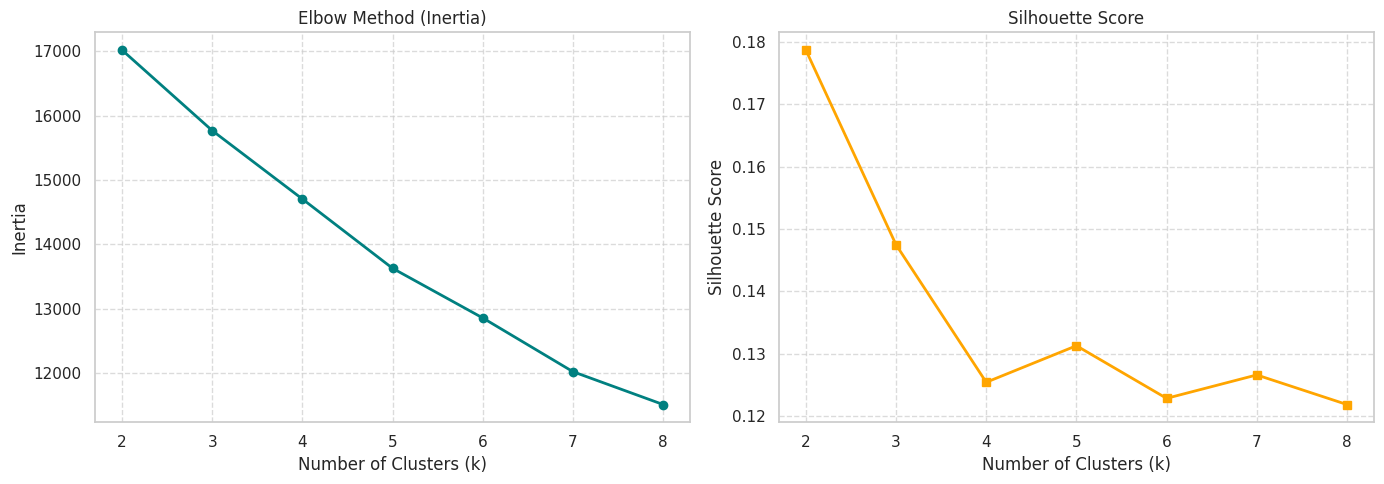

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Select specific features for segmentation
cluster_cols = ['TenureMonths', 'MonthlyUsageGB', 'MonthlyChargeEGP',
                'NumServices', 'SupportCalls6M', 'LatePayments12M', 'SatisfactionScore']
X_cluster = df[cluster_cols].copy()

# 2. Impute missing values with median
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_cluster)

# 3. Standardize the data (Crucial for distance-based algorithms)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# 4. Evaluate different values of k for K-Means
inertia = []
silhouette_scores = []
k_range = range(2, 9)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# 5. Plot Inertia and Silhouette Scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertia, marker='o', color='teal', linewidth=2)
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, linestyle='--', alpha=0.7)

axes[1].plot(k_range, silhouette_scores, marker='s', color='orange', linewidth=2)
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [9]:
from sklearn.cluster import AgglomerativeClustering, DBSCAN
import numpy as np

# 1. Apply K-Means with selected k=3
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Add K-Means labels to a dataframe for profiling
df_profile = X_cluster.copy()
df_profile['Cluster_KMeans'] = kmeans_labels

# 2. Profile every cluster (calculate mean of each feature per cluster)
print("=== K-Means Cluster Profiles (Averages) ===")
cluster_profiles = df_profile.groupby('Cluster_KMeans').mean()
display(cluster_profiles)

# 3. Apply Agglomerative Clustering
agg_cluster = AgglomerativeClustering(n_clusters=k_optimal)
agg_labels = agg_cluster.fit_predict(X_scaled)

# 4. Apply DBSCAN
# Using eps=1.5 and min_samples=5 as a starting point for standardized data
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Calculate noise points
noise_points = list(dbscan_labels).count(-1)
total_points = len(dbscan_labels)

print("\n=== DBSCAN Results ===")
print(f"Number of clusters found: {len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)}")
print(f"Number of noise points (Label -1): {noise_points} out of {total_points} ({round(noise_points/total_points*100, 2)}%)")
print("Note: Label -1 represents outliers or noise that do not belong to any dense cluster.")

# Store final K-Means labels in the main dataset for the Customer 360 output later
df['Segment'] = kmeans_labels

=== K-Means Cluster Profiles (Averages) ===


,TenureMonths,MonthlyUsageGB,MonthlyChargeEGP,NumServices,SupportCalls6M,LatePayments12M,SatisfactionScore
Cluster_KMeans,,,,,,,
0,25.093043,254.864753,589.419983,4.976522,1.630435,1.125217,3.488909
1,24.392384,206.665372,500.611540,3.913907,4.276490,1.067881,3.495756
2,26.510433,218.898604,386.705273,1.972713,1.734350,1.118780,3.478758



=== DBSCAN Results ===
Number of clusters found: 1
Number of noise points (Label -1): 119 out of 3000 (3.97%)
Note: Label -1 represents outliers or noise that do not belong to any dense cluster.


## Part F — PCA & Anomaly Detection

* Apply PCA with two components to the standardized segmentation data.
* Report explained variance.
* Plot a PC1/PC2 scatter plot colored by K-Means segment.
* Apply Isolation Forest to detect anomalies.
* Investigate unusual customers.

=== PCA Explained Variance ===
Explained Variance Ratio by Component: [0.262416  0.1495416]
Total Variance Explained by 2 Components: 0.4120


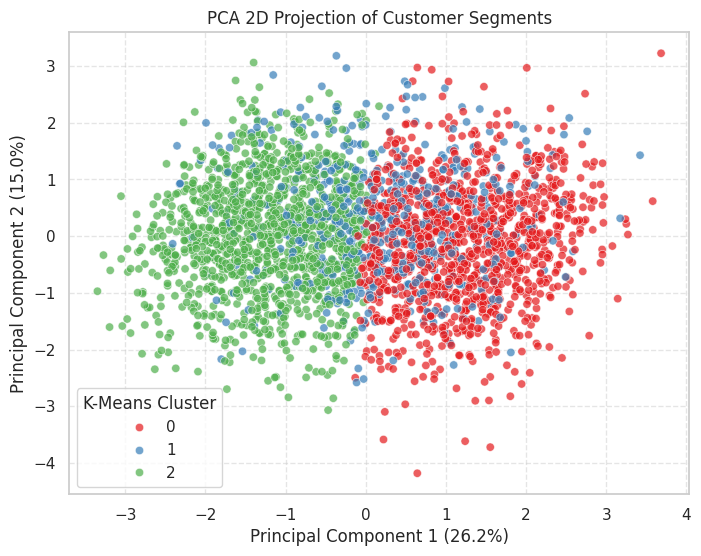


=== Anomaly Detection Results ===
Detected 150 unusual customers.
Note: These represent unusual behavioral patterns, not necessarily fraud.


,CustomerID,TenureMonths,MonthlyUsageGB,MonthlyChargeEGP,SupportCalls6M,Segment
53,CUST-00054,45,130.3,629.53,2,0
77,CUST-00078,17,224.9,368.48,6,1
97,CUST-00098,17,113.9,543.56,0,0
100,CUST-00101,19,227.3,296.46,2,2
112,CUST-00113,72,433.0,722.50,2,0
121,CUST-00122,9,324.9,665.43,5,1
151,CUST-00152,19,57.1,286.01,4,2
169,CUST-00170,26,227.4,623.08,3,0
189,CUST-00190,48,66.5,233.28,2,2
193,CUST-00194,68,292.2,394.88,0,2


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

# 1. Apply PCA with 2 components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("=== PCA Explained Variance ===")
print(f"Explained Variance Ratio by Component: {pca.explained_variance_ratio_}")
print(f"Total Variance Explained by 2 Components: {sum(pca.explained_variance_ratio_):.4f}")

# 2. Scatter plot PC1/PC2 colored by K-Means segment
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Segment'], palette='Set1', alpha=0.7)
plt.title('PCA 2D Projection of Customer Segments')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(title='K-Means Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 3. Apply Isolation Forest for Anomaly Detection
# Contamination defines the expected proportion of outliers (e.g., 5%)
iso_forest = IsolationForest(contamination=0.05, random_state=42)
anomaly_preds = iso_forest.fit_predict(X_scaled)

# Isolation Forest outputs 1 for normal, -1 for anomaly. Convert to 0/1 flag.
df['Anomaly_Flag'] = [1 if x == -1 else 0 for x in anomaly_preds]

# 4. Investigate unusual customers
anomalies = df[df['Anomaly_Flag'] == 1]
print("\n=== Anomaly Detection Results ===")
print(f"Detected {len(anomalies)} unusual customers.")
print("Note: These represent unusual behavioral patterns, not necessarily fraud.")

# Display 10 anomalies to investigate their stats
display(anomalies[['CustomerID', 'TenureMonths', 'MonthlyUsageGB', 'MonthlyChargeEGP', 'SupportCalls6M', 'Segment']].head(10))

## Part G — Customer 360 Integration

Create a final table containing:
* CustomerID
* churn probability
* predicted 12-month revenue
* customer segment
* anomaly flag
* retention-priority flag

Define and explain a reasonable retention-priority rule.
Save the final output to `outputs/customer_360_predictions.csv`.

In [11]:
import os
import numpy as np
import pandas as pd

# 1. Generate predictions for the entire dataset
# Transform full dataset using the fitted preprocessor
X_full = preprocessor.transform(X)

# Predict Churn Probability using the tuned Random Forest (best_rf)
churn_probs = best_rf.predict_proba(X_full)[:, 1]

# Predict Revenue using the best Regression Model (best_model - Gradient Boosting)
predicted_revenue = best_model.predict(X_full)

# 2. Build the final Customer 360 Table
c360_df = pd.DataFrame({
    'CustomerID': df['CustomerID'],
    'Churn_Probability': np.round(churn_probs, 4),
    'Predicted_12M_Revenue_EGP': np.round(predicted_revenue, 2),
    'Customer_Segment': df['Segment'],
    'Anomaly_Flag': df['Anomaly_Flag']
})

# 3. Define Retention Priority Rule
# Rule: Churn Probability >= 0.40 AND Predicted Revenue >= Median Revenue
revenue_threshold = c360_df['Predicted_12M_Revenue_EGP'].median()

c360_df['Retention_Priority'] = np.where(
    (c360_df['Churn_Probability'] >= 0.40) &
    (c360_df['Predicted_12M_Revenue_EGP'] >= revenue_threshold),
    1, 0
)

# Print Explanation
print("=== Retention Priority Rule ===")
print(f"Rule Logic: Churn Probability >= 0.40 AND Predicted Revenue >= {revenue_threshold:.2f} (Median)")
print("Explanation: We prioritize retaining customers who have a high likelihood of leaving ")
print("AND are expected to generate above-average revenue. This maximizes the ROI of retention campaigns.")

# 4. Display a sample of the final table
print("\n=== Customer 360 Final Table (Sample) ===")
display(c360_df.head(10))
print(f"\nTotal High-Priority Customers to Retain: {c360_df['Retention_Priority'].sum()}")

# 5. Save output to CSV
os.makedirs('outputs', exist_ok=True)
output_path = 'outputs/customer_360_predictions.csv'
c360_df.to_csv(output_path, index=False)
print(f"\nFile successfully saved to: {output_path}")

=== Retention Priority Rule ===
Rule Logic: Churn Probability >= 0.40 AND Predicted Revenue >= 5302.55 (Median)
Explanation: We prioritize retaining customers who have a high likelihood of leaving 
AND are expected to generate above-average revenue. This maximizes the ROI of retention campaigns.

=== Customer 360 Final Table (Sample) ===


,CustomerID,Churn_Probability,Predicted_12M_Revenue_EGP,Customer_Segment,Anomaly_Flag,Retention_Priority
0,CUST-00001,0.4863,5979.58,1,0,1
1,CUST-00002,0.1667,4222.89,2,0,0
2,CUST-00003,0.1610,4086.88,1,0,0
3,CUST-00004,0.0917,4206.13,2,0,0
4,CUST-00005,0.1442,4756.18,1,0,0
5,CUST-00006,0.0838,5317.24,2,0,0
6,CUST-00007,0.5506,3986.81,2,0,0
7,CUST-00008,0.0262,5554.16,2,0,0
8,CUST-00009,0.1174,3494.99,2,0,0
9,CUST-00010,0.0742,4291.24,2,0,0



Total High-Priority Customers to Retain: 161

File successfully saved to: outputs/customer_360_predictions.csv


## Final Submission Requirements

### Three to Five Business Recommendations
1. **Target Month-to-Month Contracts:** Since these customers showed the highest churn rate, the business should incentivize them to switch to 1-year or 2-year contracts (e.g., by offering a discounted first month for upgrading).
2. **Focus on High-Risk/High-Value Segments:** The 161 customers identified by the `Retention_Priority` flag should immediately receive targeted retention offers. Saving these accounts directly protects above-average revenue.
3. **Monitor the 'High-Support' Cluster:** Cluster 1 showed a significantly higher average of support calls. The business needs to investigate the root causes of these complaints (network issues, billing errors) and proactively resolve them before these customers churn.
4. **Encourage AutoPay Adoption:** The EDA showed that customers without AutoPay are more likely to churn. Offering a small recurring discount for enabling AutoPay could improve retention and cash flow.

### Challenge Questions Answers

**1. What changes when the churn threshold moves from 0.50 to 0.35 or 0.70?**
* **Moving to 0.35:** Increases Recall (identifies more potential churners) but decreases Precision (more false alarms/false positives).
* **Moving to 0.70:** Increases Precision (the model is very confident when it flags someone) but decreases Recall (misses many actual churners).

**2. When is recall more important than precision for churn?**
Recall is more important when the cost of retaining a customer (e.g., sending an email or offering a small discount) is much lower than the cost of acquiring a new customer to replace a lost one. We want to catch as many potential churners as possible.

**3. Why must CustomerID be excluded from model features?**
It is a unique identifier with no predictive power. Including it causes the model to memorize the dataset (overfitting) rather than learning generalizable patterns.

**4. Why is one-hot encoding required?**
Most Machine Learning algorithms require numerical input. One-Hot Encoding converts categorical variables into binary vectors without imposing a false ordinal relationship (which Label Encoding might do for nominal data like Region or InternetType).

**5. Which algorithms are most sensitive to scaling?**
Distance-based algorithms (like KNN, K-Means, SVM, and PCA) and gradient descent-based algorithms (like Logistic Regression or Neural Networks).

**6. Can a cluster be considered useful only because its silhouette score is high?**
No. A high silhouette score only indicates statistical and geometric separation. For a cluster to be truly useful, it must have **Business Interpretability** (i.e., actionable insights like "High-Value Users" or "At-Risk Users").

**7. How would you monitor model drift after deployment?**
By continuously tracking **Data Drift** (changes in the input feature distributions, e.g., economic changes affecting monthly charges) and **Concept Drift** (changes in the relationship between inputs and the target, measured by comparing predicted churn rates to actual real-world churn over time).

**8. What risks exist if retention offers are automatically assigned by a model?**
* **Revenue Cannibalization:** Giving discounts to false positives (customers who weren't actually going to leave).
* **Conditioning:** Customers might learn to artificially trigger "churn-like" behavior just to receive automated discounts.
* **Retaining Unprofitable Customers:** Not all churners are worth saving if their cost to serve exceeds their revenue.